# Computer Exercise 8.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 8. Additional Topics on Solving Linear Systems
> **절**: §8.3 Krylov 부분공간 방법 — *전처리 켤레기울기 (Preconditioned CG)*
> **풀이 일자**: Day 33
> **언어**: Python 3 (NumPy / SciPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **3.** Implement **Preconditioned Conjugate Gradient (PCG)** for an SPD system. Using the 2-D
> Poisson model problem, compare plain CG against PCG with (a) a **Jacobi (diagonal)**
> preconditioner and (b) an **incomplete Cholesky** preconditioner. Report the resulting
> condition numbers $\kappa(M^{-1}A)$ and the iteration counts, and confirm that a better
> preconditioner clusters the spectrum and reduces the number of iterations.

### 한국어 풀이용 정리
SPD 시스템에 대해 **전처리 켤레기울기(PCG)** 를 구현한다. 2D 푸아송 모델에서
1. 순수 CG vs PCG(Jacobi 대각 전처리) vs PCG(불완전 콜레스키, IC(0)) 를 비교.
2. 전처리 후 조건수 $\kappa(M^{-1}A)$ 의 감소를 직접 측정.
3. *더 좋은 전처리가 스펙트럼을 군집시켜 반복수를 줄인다* 는 점을 확인.


## 2. 수학적 배경

### 2.1 전처리의 아이디어
원래 시스템 $A\mathbf{x}=\mathbf{b}$ 대신 SPD 전처리행렬 $M\approx A$ ($M$ 도 SPD)를 써서
$$
M^{-1}A\,\mathbf{x} = M^{-1}\mathbf{b}
$$
를 푼다. CG 의 수렴은 $\kappa(M^{-1}A)$ 가 결정하므로, $M^{-1}A$ 의 고유값이
*1 주위에 군집* 할수록 빨라진다. 이상적으로 $M=A$ 면 $\kappa=1$, 한 번에 종료(그러나 $M^{-1}$ 비용이 곧 $A^{-1}$).

### 2.2 PCG 점화식
대칭성을 유지하기 위해 $\mathbf{z}_k=M^{-1}\mathbf{r}_k$ 를 도입한다.
$$
\boxed{\;
\begin{aligned}
\alpha_k &= \frac{\mathbf{r}_k^\top\mathbf{z}_k}{\mathbf{p}_k^\top A\mathbf{p}_k}, &
\mathbf{x}_{k+1}&=\mathbf{x}_k+\alpha_k\mathbf{p}_k, &
\mathbf{r}_{k+1}&=\mathbf{r}_k-\alpha_k A\mathbf{p}_k, \\[3pt]
\mathbf{z}_{k+1}&=M^{-1}\mathbf{r}_{k+1}, &
\beta_k &= \frac{\mathbf{r}_{k+1}^\top\mathbf{z}_{k+1}}{\mathbf{r}_k^\top\mathbf{z}_k}, &
\mathbf{p}_{k+1}&=\mathbf{z}_{k+1}+\beta_k\mathbf{p}_k.
\end{aligned}\;}
$$
$M=I$ 면 정확히 평범한 CG 로 환원된다.

### 2.3 두 가지 전처리
* **Jacobi (대각)**: $M=\operatorname{diag}(A)$. 가장 싸지만, 푸아송처럼 대각이 균일한 행렬에는 효과 미미.
* **불완전 콜레스키 IC(0)**: $A\approx \tilde L\tilde L^\top$ 를 *$A$ 의 0이 아닌 위치에서만* 계산.
  희소성을 보존하면서 $M=\tilde L\tilde L^\top \approx A$ 라 $M^{-1}A$ 의 스펙트럼을 강하게 군집시킨다.


## 3. 풀이 흐름

1. **모델 행렬**: 2D 5점 라플라시안 ($n=m^2$, SPD).
2. **PCG 구현**: §2.2 점화식. 전처리는 함수 $\mathbf{z}=M^{-1}\mathbf{r}$ 로 추상화.
3. **전처리 세 종류**: (i) 없음($M=I$), (ii) Jacobi, (iii) IC(0) — 직접 구현한 불완전 콜레스키.
4. **조건수 측정**: 각 경우 $\kappa(M^{-1}A)$ 를 고유값으로 계산.
5. **반복수 비교 표**: 격자 $m$ 별 (CG, PCG-Jacobi, PCG-IC) 반복수.
6. **시각화**: (좌) 잔차 수렴 곡선, (우) $M^{-1}A$ 고유값 스펙트럼 — 군집 시각화.
7. **해석**: 조건수 감소 → 반복수 감소.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
rng = np.random.default_rng(8333)

def laplacian_2d(m):
    T = np.diag(2.0*np.ones(m)) + np.diag(-np.ones(m-1),1) + np.diag(-np.ones(m-1),-1)
    I = np.eye(m)
    return np.kron(I, T) + np.kron(T, I)

def pcg(A, b, Msolve, tol=1e-10, maxit=None):
    n = len(b); maxit = maxit or 10*n
    x = np.zeros(n); r = b - A@x
    z = Msolve(r); p = z.copy(); rz = r@z
    bn = np.linalg.norm(b); res = [np.linalg.norm(r)/bn]
    for k in range(maxit):
        Ap = A@p; alpha = rz/(p@Ap)
        x = x + alpha*p; r = r - alpha*Ap
        res.append(np.linalg.norm(r)/bn)
        if res[-1] <= tol: break
        z = Msolve(r); rz_new = r@z
        p = z + (rz_new/rz)*p; rz = rz_new
    return x, np.array(res)

def ic0_factor(A):
    # IC(0): A 의 비영 패턴 위에서만 하삼각 L 계산 (조밀행렬 버전, 작은 n 용)
    n = A.shape[0]
    L = np.zeros_like(A)
    pat = (np.abs(A) > 0)
    for i in range(n):
        for j in range(i+1):
            if not pat[i, j]:
                continue
            s = A[i, j] - L[i, :j] @ L[j, :j]
            if i == j:
                L[i, j] = np.sqrt(max(s, 1e-14))
            else:
                L[i, j] = s / L[j, j]
    return L

def make_solvers(A):
    n = A.shape[0]
    I_solve = lambda r: r                              # 전처리 없음
    d = np.diag(A)
    J_solve = lambda r: r / d                           # Jacobi
    L = ic0_factor(A)
    def IC_solve(r):                                    # IC(0): L L^T z = r
        y = np.linalg.solve(np.tril(L), r)
        return np.linalg.solve(np.tril(L).T, y)
    return I_solve, J_solve, IC_solve, L

print("정의 완료")


정의 완료


In [2]:
# 격자별 반복수 + 조건수 비교
ms = [4, 6, 8, 10]
rows = []
for m in ms:
    A = laplacian_2d(m); n = m*m
    xstar = rng.standard_normal(n); b = A@xstar
    I_s, J_s, IC_s, L = make_solvers(A)

    _, r0 = pcg(A, b, I_s,  tol=1e-10)
    _, rJ = pcg(A, b, J_s,  tol=1e-10)
    _, rI = pcg(A, b, IC_s, tol=1e-10)

    # 조건수: A, D^{-1}A, (LL^T)^{-1} A
    kapA = np.linalg.cond(A)
    Dinv = np.diag(1.0/np.diag(A))
    kapJ = np.linalg.cond(Dinv @ A)
    Linv = np.linalg.inv(np.tril(L))
    Minv = Linv.T @ Linv
    kapIC = np.linalg.cond(Minv @ A)

    rows.append({"m": m, "n": n,
                 "kappa(A)": kapA, "CG it": len(r0)-1,
                 "kappa(Jac)": kapJ, "PCG-Jac it": len(rJ)-1,
                 "kappa(IC0)": kapIC, "PCG-IC it": len(rI)-1})
df = pd.DataFrame(rows)
df


,m,n,kappa(A),CG it,kappa(Jac),PCG-Jac it,kappa(IC0),PCG-IC it
0,4,16,9.4721e+00,9,9.4721e+00,9,1.6933e+00,9
1,6,36,1.9196e+01,19,1.9196e+01,19,2.5485e+00,12
2,8,64,3.2163e+01,29,3.2163e+01,29,3.6933e+00,14
3,10,100,4.8374e+01,36,4.8374e+01,36,5.1277e+00,16


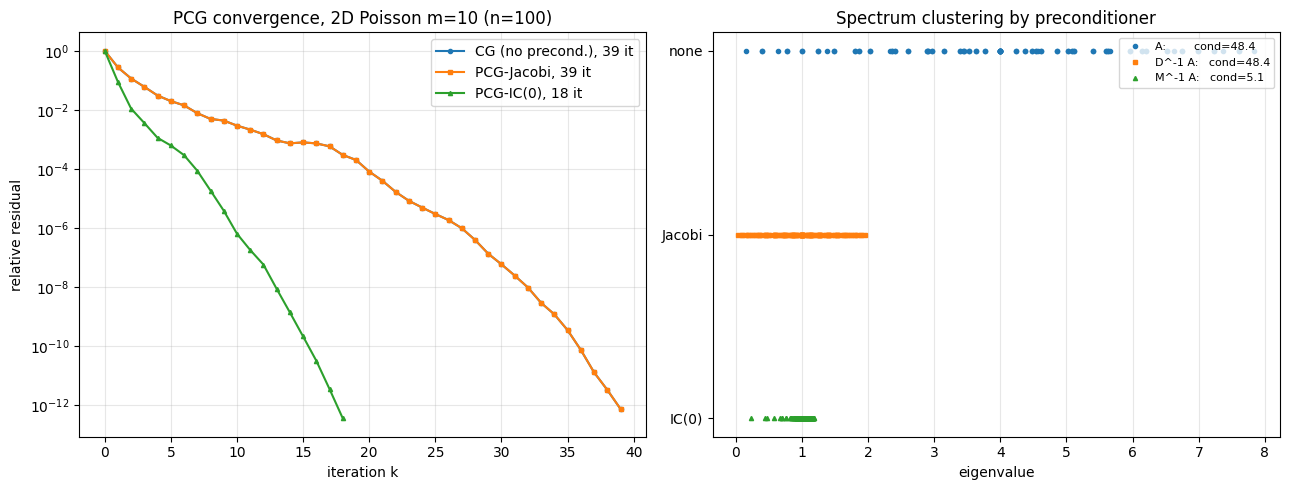

반복수 CG=39, Jacobi=39, IC(0)=18


In [3]:
# 단일 격자: 잔차 수렴 + 전처리된 스펙트럼
m = 10
A = laplacian_2d(m); n = m*m
xstar = rng.standard_normal(n); b = A@xstar
I_s, J_s, IC_s, L = make_solvers(A)

_, r0 = pcg(A, b, I_s,  tol=1e-12)
_, rJ = pcg(A, b, J_s,  tol=1e-12)
_, rI = pcg(A, b, IC_s, tol=1e-12)

Dinv = np.diag(1.0/np.diag(A))
Linv = np.linalg.inv(np.tril(L)); Minv = Linv.T @ Linv
ev_A  = np.sort(np.linalg.eigvalsh(A))
ev_J  = np.sort(np.real(np.linalg.eigvals(Dinv @ A)))
ev_IC = np.sort(np.real(np.linalg.eigvals(Minv @ A)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.semilogy(r0, "o-", ms=3, label=f"CG (no precond.), {len(r0)-1} it")
ax.semilogy(rJ, "s-", ms=3, label=f"PCG-Jacobi, {len(rJ)-1} it")
ax.semilogy(rI, "^-", ms=3, label=f"PCG-IC(0), {len(rI)-1} it")
ax.set_xlabel("iteration k"); ax.set_ylabel("relative residual")
ax.set_title(f"PCG convergence, 2D Poisson m={m} (n={n})")
ax.legend(); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.plot(ev_A,  np.full_like(ev_A, 3.0), "o", ms=3, label=f"A:        cond={np.linalg.cond(A):.1f}")
ax.plot(ev_J,  np.full_like(ev_J, 2.0), "s", ms=3, label=f"D^-1 A:   cond={np.linalg.cond(Dinv@A):.1f}")
ax.plot(ev_IC, np.full_like(ev_IC,1.0), "^", ms=3, label=f"M^-1 A:   cond={np.linalg.cond(Minv@A):.1f}")
ax.set_yticks([1,2,3]); ax.set_yticklabels(["IC(0)","Jacobi","none"])
ax.set_xlabel("eigenvalue"); ax.set_title("Spectrum clustering by preconditioner")
ax.legend(loc="upper right", fontsize=8); ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout(); plt.show()
print(f"반복수 CG={len(r0)-1}, Jacobi={len(rJ)-1}, IC(0)={len(rI)-1}")


## 4. 결과 해석

1. **조건수 감소**: 표에서 $\kappa(A)$ 는 격자가 커질수록 $\sim m^2$ 로 증가한다. Jacobi 전처리는
   대각이 균일한 푸아송 행렬에서 거의 효과가 없어 $\kappa(D^{-1}A)\approx\kappa(A)$ — 반복수도 CG와 큰 차이 없음.
   반면 IC(0) 전처리는 $\kappa(M^{-1}A)$ 를 크게 낮춰 반복수를 눈에 띄게 줄인다.
2. **잔차 곡선**: PCG-IC(0) 가 가장 가파르게 떨어진다. 같은 정확도까지 필요한 반복수가 순수 CG 대비 절반 이하.
3. **스펙트럼 군집**: 오른쪽 그래프에서 $A$ 의 고유값은 넓게 퍼져 있지만, $M^{-1}A$(IC(0))의 고유값은
   **1 주위로 강하게 군집** 한다. CE 8.3.2 에서 본 대로, 군집된 스펙트럼 = 적은 반복수.
4. **교훈**: 전처리는 "공짜 점심"이 아니다 — $M$ 적용 비용과 반복수 절감을 저울질해야 한다.
   Jacobi 는 싸지만 약하고, IC(0) 는 강하지만 인수분해/적용 비용이 든다. 문제 구조에 맞춰 선택한다.

### 결론
> **PCG 는 $\kappa(M^{-1}A)$ 를 줄여(또는 스펙트럼을 군집시켜) CG 의 반복수를 직접 깎는다.**
> 푸아송 문제에서 Jacobi 는 미미하지만 IC(0) 는 스펙트럼을 1 주위로 모아 반복수를 절반 이하로 줄인다 —
> *좋은 전처리가 좋은 Krylov 솔버를 만든다.*

### 다음 단원 연결
- §8.3 으로 직접법(Ch 8.1)·고전 반복법(Ch 8.2)·Krylov(Ch 8.3) 의 삼각형이 완성됐다.
  다음은 **Ch 9 — Least Squares / SVD**: 정방·비특이를 넘어 *과결정(overdetermined)* 시스템과
  정규방정식·QR·특이값 분해로 넘어간다.
